# LUNA16 Lung Nodule Classification — End-to-End Pipeline
**Patient-level split · ResNet-50 · Binary classification (nodule / non-nodule)**

This notebook runs the full pipeline:
1. **Patch extraction** from LUNA16 `.mhd/.raw` CT volumes (subsets 7, 8, 9)
2. **Model training** with ResNet-50, OneCycleLR, weighted sampler, early stopping
3. **Comprehensive evaluation** — Accuracy, Precision, Recall, F1, Specificity, MCC, ROC-AUC, PR-AUC

**Patient-level split (no leakage):** `subset7 → train`, `subset8 → val`, `subset9 → test`


## 1 · Imports & Configuration

In [ ]:
import os, sys, time, json, random
from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

import torch
import torch.nn as nn
import torch.optim as optim
from torch.amp import GradScaler, autocast
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve,
)
from PIL import Image

random.seed(42); np.random.seed(42); torch.manual_seed(42)

# ── Paths ──
LUNA_DIR  = Path("luna16")
PATCH_DIR = Path("luna16_patches")
MODEL_DIR = Path("model_luna16"); MODEL_DIR.mkdir(exist_ok=True)
OUT_DIR   = Path("luna16_output");  OUT_DIR.mkdir(exist_ok=True)

# ── Training config ──
CLASS_NAMES = ["non_nodule", "nodule"]
NUM_CLASSES = 2
BACKBONE    = "resnet50"
IMG_SIZE    = 224
BATCH_SIZE  = 64
NUM_      = 20
LR_MAX      = 5e-4
WEIGHT_DECAY = 1e-4
GRAD_CLIP   = 1.0
EARLY_STOP_PAT = 6

device  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = device.type == "cuda"
print(f"PyTorch: {torch.__version__}")
print(f"Device:  {device}")
if device.type == "cuda":
    p = torch.cuda.get_device_properties(0)
    print(f"GPU:     {p.name} ({p.total_memory/1e9:.1f} GB)")


PyTorch: 2.6.0+cu124
Device:  cuda
GPU:     NVIDIA GeForce RTX 4060 Laptop GPU (8.6 GB)


## 2 · Patch Extraction

Reads `.mhd/.raw` CT volumes and extracts 64×64 axial patches (50 mm physical window) around candidate coordinates from `candidates_V2.csv`.
- HU windowing: `[-1000, 400]` (lung tissue)
- Negatives sampled at 3:1 ratio per patient
- **If patches already exist, this step is skipped** (idempotent).


In [2]:
PATCH_MM  = 50; PATCH_PX  = 64; NEG_RATIO = 3
HU_WIN    = (-1000, 400)
SPLITS = {"subset7": "train", "subset8": "val", "subset9": "test"}

def _already_extracted():
    if not PATCH_DIR.exists(): return False
    for split in SPLITS.values():
        for cls in CLASS_NAMES:
            d = PATCH_DIR / split / cls
            if not d.exists() or not any(d.iterdir()):
                return False
    return True

if _already_extracted():
    print("Patches already extracted — skipping extraction.")
    # Show counts
    for split in SPLITS.values():
        n_pos = len(list((PATCH_DIR/split/"nodule").glob("*.png")))
        n_neg = len(list((PATCH_DIR/split/"non_nodule").glob("*.png")))
        print(f"  {split:<6}  nodule={n_pos:>4}  non_nodule={n_neg:>4}  total={n_pos+n_neg:>4}")
else:
    import SimpleITK as sitk
    PATCH_DIR.mkdir(exist_ok=True)

    def world_to_voxel(world_xyz, origin, spacing, direction):
        D = np.array(direction).reshape(3, 3)
        voxel = np.linalg.inv(D) @ ((np.array(world_xyz) - np.array(origin)) / np.array(spacing))
        return np.round(voxel).astype(int)

    def window_hu(arr, lo=HU_WIN[0], hi=HU_WIN[1]):
        arr = np.clip(arr, lo, hi)
        return ((arr - lo) / (hi - lo) * 255.0).astype(np.uint8)

    def extract_patch(vol_np, spacing, vx_xyz, patch_mm=PATCH_MM, patch_px=PATCH_PX):
        z = vx_xyz[2]
        if z < 0 or z >= vol_np.shape[0]: return None
        slice2d = vol_np[z]
        half_x = int(round((patch_mm / 2) / spacing[0]))
        half_y = int(round((patch_mm / 2) / spacing[1]))
        cx, cy = vx_xyz[0], vx_xyz[1]
        y0, y1 = cy - half_y, cy + half_y
        x0, x1 = cx - half_x, cx + half_x
        if y0 < 0 or x0 < 0 or y1 > slice2d.shape[0] or x1 > slice2d.shape[1]:
            return None
        crop = window_hu(slice2d[y0:y1, x0:x1])
        return Image.fromarray(crop).resize((patch_px, patch_px), Image.BILINEAR)

    cand = pd.read_csv(LUNA_DIR / "candidates_V2.csv")
    print(f"Loaded candidates_V2.csv: {len(cand):,} rows")
    for subset, split in SPLITS.items():
        inner = LUNA_DIR / subset / subset
        if not inner.exists(): inner = LUNA_DIR / subset
        mhd_files = sorted(inner.glob("*.mhd"))
        (PATCH_DIR/split/"nodule").mkdir(parents=True, exist_ok=True)
        (PATCH_DIR/split/"non_nodule").mkdir(parents=True, exist_ok=True)
        n_pos = n_neg = 0
        for mhd in mhd_files:
            uid = mhd.stem
            pat = cand[cand.seriesuid == uid]
            if len(pat) == 0: continue
            try:
                vol = sitk.ReadImage(str(mhd))
                arr = sitk.GetArrayFromImage(vol)
                origin, spacing, direction = vol.GetOrigin(), vol.GetSpacing(), vol.GetDirection()
            except Exception:
                continue
            pos = pat[pat["class"] == 1]
            neg = pat[pat["class"] == 0]
            n_neg_target = max(NEG_RATIO * max(len(pos), 1), 3)
            if len(neg) > n_neg_target: neg = neg.sample(n=n_neg_target, random_state=42)
            for _, r in pos.iterrows():
                vx = world_to_voxel((r.coordX, r.coordY, r.coordZ), origin, spacing, direction)
                img = extract_patch(arr, spacing, vx)
                if img is not None:
                    img.save(PATCH_DIR/split/"nodule"/f"{uid}_{int(r.coordX)}_{int(r.coordY)}_{int(r.coordZ)}.png")
                    n_pos += 1
            for _, r in neg.iterrows():
                vx = world_to_voxel((r.coordX, r.coordY, r.coordZ), origin, spacing, direction)
                img = extract_patch(arr, spacing, vx)
                if img is not None:
                    img.save(PATCH_DIR/split/"non_nodule"/f"{uid}_{int(r.coordX)}_{int(r.coordY)}_{int(r.coordZ)}.png")
                    n_neg += 1
        print(f"  {split}: nodule={n_pos}  non_nodule={n_neg}  (from {len(mhd_files)} CTs)")


Patches already extracted — skipping extraction.
  train   nodule= 120  non_nodule= 465  total= 585
  val     nodule= 194  non_nodule= 672  total= 866
  test    nodule= 143  non_nodule= 519  total= 662


## 3 · Dataset Composition & Sample Patches

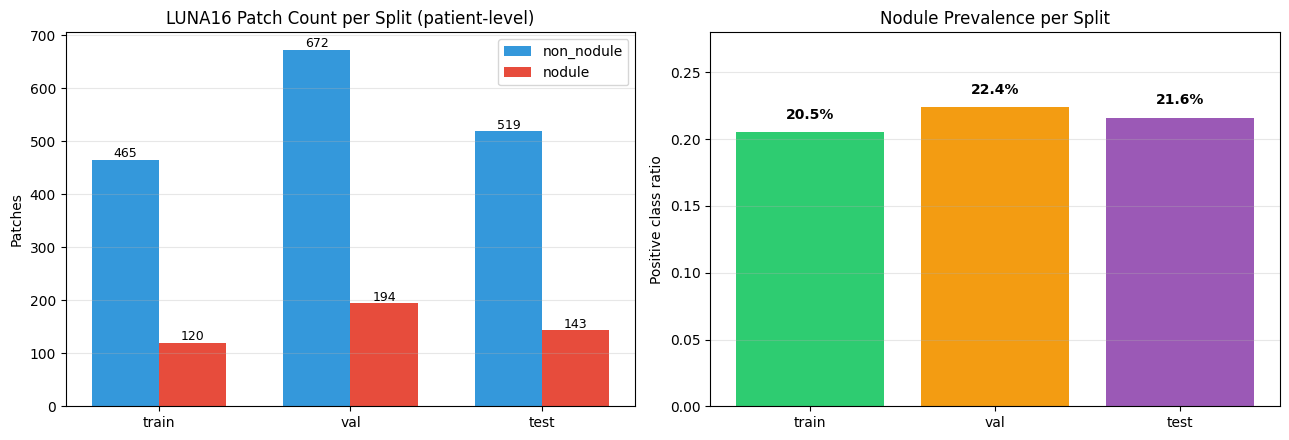

  train   nodule= 120  non_nodule= 465  total= 585  prevalence=20.51%
  val     nodule= 194  non_nodule= 672  total= 866  prevalence=22.40%
  test    nodule= 143  non_nodule= 519  total= 662  prevalence=21.60%


In [3]:
# Count patches and plot class distribution
split_counts = {}
for split in ["train", "val", "test"]:
    split_counts[split] = {
        "nodule":     len(list((PATCH_DIR/split/"nodule").glob("*.png"))),
        "non_nodule": len(list((PATCH_DIR/split/"non_nodule").glob("*.png"))),
    }

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
splits = list(split_counts.keys())
n_nod  = [split_counts[s]["nodule"]     for s in splits]
n_non  = [split_counts[s]["non_nodule"] for s in splits]
x = np.arange(len(splits)); w = 0.35
ax[0].bar(x - w/2, n_non, w, label="non_nodule", color="#3498db")
ax[0].bar(x + w/2, n_nod, w, label="nodule",     color="#e74c3c")
for i, s in enumerate(splits):
    ax[0].text(i-w/2, n_non[i]+5, n_non[i], ha="center", fontsize=9)
    ax[0].text(i+w/2, n_nod[i]+5, n_nod[i], ha="center", fontsize=9)
ax[0].set(xticks=x, xticklabels=splits, ylabel="Patches",
          title="LUNA16 Patch Count per Split (patient-level)")
ax[0].legend(); ax[0].grid(axis="y", alpha=0.3)

# Prevalence
prev = [n_nod[i]/(n_nod[i]+n_non[i]) for i in range(3)]
ax[1].bar(splits, prev, color=["#2ecc71","#f39c12","#9b59b6"])
for i, p in enumerate(prev):
    ax[1].text(i, p+0.01, f"{p:.1%}", ha="center", fontweight="bold")
ax[1].set(ylim=(0, max(prev)*1.25), ylabel="Positive class ratio",
          title="Nodule Prevalence per Split")
ax[1].grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

for s in splits:
    tot = sum(split_counts[s].values())
    print(f"  {s:<6}  nodule={split_counts[s]['nodule']:>4}  "
          f"non_nodule={split_counts[s]['non_nodule']:>4}  total={tot:>4}  "
          f"prevalence={split_counts[s]['nodule']/tot:.2%}")


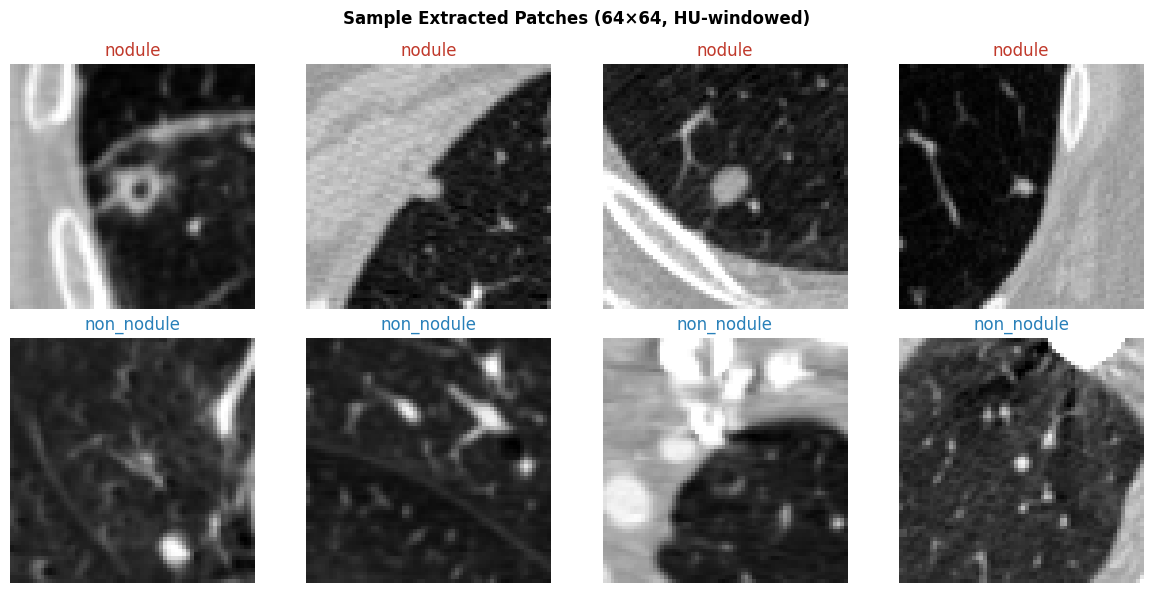

In [4]:
# Show sample patches — 4 nodule + 4 non_nodule
fig, ax = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle("Sample Extracted Patches (64×64, HU-windowed)", fontsize=12, fontweight="bold")
for row, cls in enumerate(["nodule", "non_nodule"]):
    files = list((PATCH_DIR/"train"/cls).glob("*.png"))[:4]
    for col, f in enumerate(files):
        img = Image.open(f)
        ax[row, col].imshow(img, cmap="gray")
        ax[row, col].set_title(cls, color="#c0392b" if cls=="nodule" else "#2980b9")
        ax[row, col].axis("off")
plt.tight_layout(); plt.show()


## 4 · Training Setup — Transforms, Loaders, Model, Optimizer

In [5]:
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE + 16, IMG_SIZE + 16)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.12)),
])
eval_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_ds = datasets.ImageFolder(PATCH_DIR/"train", transform=train_tf)
val_ds   = datasets.ImageFolder(PATCH_DIR/"val",   transform=eval_tf)
test_ds  = datasets.ImageFolder(PATCH_DIR/"test",  transform=eval_tf)

train_labels = [y for _, y in train_ds.samples]
counts_tr    = np.bincount(train_labels, minlength=NUM_CLASSES).astype(float)
w_cls        = 1.0 / (counts_tr + 1e-8)
sampler      = WeightedRandomSampler([w_cls[l] for l in train_labels],
                                      num_samples=len(train_labels), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0, pin_memory=USE_AMP)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,  num_workers=0, pin_memory=USE_AMP)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,  num_workers=0, pin_memory=USE_AMP)

# Model
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
in_f  = model.fc.in_features
model.fc = nn.Sequential(nn.BatchNorm1d(in_f), nn.Dropout(0.4), nn.Linear(in_f, NUM_CLASSES))
model = model.to(device)

cls_weights = torch.tensor(1.0 / (counts_tr / counts_tr.sum()), dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=cls_weights)
optimizer = optim.AdamW(model.parameters(), lr=LR_MAX/25, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=LR_MAX, steps_per_epoch=len(train_loader), epochs=NUM_EPOCHS,
    pct_start=0.3, anneal_strategy="cos", div_factor=25, final_div_factor=1e4)
scaler = GradScaler('cuda', enabled=USE_AMP)

print(f"Model:   resnet50  (params: {sum(p.numel() for p in model.parameters()):,})")
print(f"Classes weights: {dict(zip(CLASS_NAMES, cls_weights.cpu().numpy().round(3)))}")
print(f"Train/Val/Test:  {len(train_ds)} / {len(val_ds)} / {len(test_ds)} patches")


Model:   resnet50  (params: 23,516,226)
Classes weights: {'non_nodule': np.float32(4.875), 'nodule': np.float32(1.258)}
Train/Val/Test:  585 / 866 / 662 patches


## 5 · Training Loop with Early Stopping (patience = 6)

In [6]:
def compute(y_true, y_pred, y_score=None):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    rec  = recall_score(y_true,    y_pred, pos_label=1, zero_division=0)
    f1   = f1_score(y_true,        y_pred, pos_label=1, zero_division=0)
    auc  = roc_auc_score(y_true, y_score) if y_score is not None else None
    return acc, prec, rec, f1, auc

def train_epoch():
    model.train(); rl, yp, yt = 0.0, [], []
    for imgs, lbs in train_loader:
        imgs, lbs = imgs.to(device), lbs.to(device)
        optimizer.zero_grad()
        with autocast('cuda', enabled=USE_AMP):
            out = model(imgs); loss = criterion(out, lbs)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer); scaler.update(); scheduler.step()
        rl += loss.item()*imgs.size(0)
        yp.extend(out.argmax(1).cpu().numpy()); yt.extend(lbs.cpu().numpy())
    return rl/len(train_loader.dataset), *compute(yt, yp)[:4]

@torch.no_grad()
def evaluate(loader):
    model.eval(); rl, yp, yt, ys = 0.0, [], [], []
    for imgs, lbs in loader:
        imgs, lbs = imgs.to(device), lbs.to(device)
        with autocast('cuda', enabled=USE_AMP):
            out = model(imgs); loss = criterion(out, lbs)
        rl += loss.item()*imgs.size(0)
        probs = torch.softmax(out.float(), dim=1)[:, 1]
        yp.extend(out.argmax(1).cpu().numpy())
        ys.extend(probs.cpu().numpy())
        yt.extend(lbs.cpu().numpy())
    return rl/len(loader.dataset), np.array(yt), np.array(yp), np.array(ys)

history = {k: [] for k in ["train_loss","val_loss","train_acc","val_acc",
                            "train_f1","val_f1","val_prec","val_rec","val_auc"]}
best_f1, early_ctr = 0.0, 0
best_ckpt = MODEL_DIR / f"best_{BACKBONE}.pth"

print(f"{'Ep':>3} {'TrLoss':>7} {'TrAcc':>6} {'TrF1':>6} {'VaLoss':>7} "
      f"{'VaAcc':>6} {'VaF1':>6} {'VaP':>6} {'VaR':>6} {'AUC':>6} {'LR':>8} {'s':>4}")
print("-"*96)

for ep in range(1, NUM_EPOCHS+1):
    t0 = time.time()
    tr_loss, tr_acc, tr_p, tr_r, tr_f1 = train_epoch()
    va_loss, vy, vp, vs = evaluate(val_loader)
    va_acc, va_p, va_r, va_f1, va_auc = compute(vy, vp, vs)
    dt = time.time()-t0
    lr = optimizer.param_groups[0]["lr"]
    for k, v in [("train_loss",tr_loss),("val_loss",va_loss),
                  ("train_acc",tr_acc),("val_acc",va_acc),
                  ("train_f1",tr_f1),("val_f1",va_f1),
                  ("val_prec",va_p),("val_rec",va_r),("val_auc",va_auc)]:
        history[k].append(v)
    print(f"{ep:>3} {tr_loss:>7.4f} {tr_acc*100:>5.1f}% {tr_f1:.4f} "
          f"{va_loss:>7.4f} {va_acc*100:>5.1f}% {va_f1:.4f} "
          f"{va_p:.4f} {va_r:.4f} {va_auc:.4f} {lr:.2e} {dt:>3.0f}s")
    if va_f1 > best_f1:
        best_f1 = va_f1; early_ctr = 0
        torch.save({"epoch": ep, "backbone": BACKBONE,
                     "model_state_dict": model.state_dict(),
                     "val_f1": va_f1, "val_auc": va_auc}, best_ckpt)
        print(f"    [*] best saved  val_f1={va_f1:.4f}  val_auc={va_auc:.4f}")
    else:
        early_ctr += 1
        if early_ctr >= EARLY_STOP_PAT:
            print(f"\nEarly stop at epoch {ep}"); break

# Save history
(OUT_DIR/"history.json").write_text(json.dumps(history, indent=2))
print("\nTraining complete. Best val_f1 =", round(best_f1, 4))


 Ep  TrLoss  TrAcc   TrF1  VaLoss  VaAcc   VaF1    VaP    VaR    AUC       LR    s
------------------------------------------------------------------------------------------------


C:\Users\PC\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\optim\lr_scheduler.py:227: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


  1  0.8133  49.6% 0.4974  0.7428  36.8% 0.4224 0.7273 0.2976 0.4444 5.32e-05   9s
    [*] best saved  val_f1=0.4224  val_auc=0.4444


  2  0.7588  52.5% 0.5336  0.7420  40.3% 0.4541 0.7818 0.3199 0.5168 1.44e-04   8s
    [*] best saved  val_f1=0.4541  val_auc=0.5168


  3  0.7013  59.1% 0.5983  0.6950  53.9% 0.6402 0.8124 0.5283 0.5820 2.66e-04   8s
    [*] best saved  val_f1=0.6402  val_auc=0.5820


...

 16  0.0882  94.9% 0.9500  0.2158  93.0% 0.9550 0.9460 0.9643 0.9561 8.98e-05   8s
    [*] best saved  val_f1=0.9550  val_auc=0.9561


 17  0.0969  95.6% 0.9534  0.2305  91.7% 0.9471 0.9348 0.9598 0.9600 5.11e-05   8s


 18  0.0561  96.2% 0.9627  0.2230  92.8% 0.9547 0.9382 0.9717 0.9613 2.24e-05   8s


 19  0.0626  96.9% 0.9684  0.2053  93.6% 0.9595 0.9491 0.9702 0.9649 5.08e-06   8s
    [*] best saved  val_f1=0.9595  val_auc=0.9649


 20  0.0619  95.7% 0.9588  0.2116  92.8% 0.9544 0.9433 0.9658 0.9642 6.49e-08   8s

Training complete. Best val_f1 = 0.9595


## 6 · Training Curves (inline)

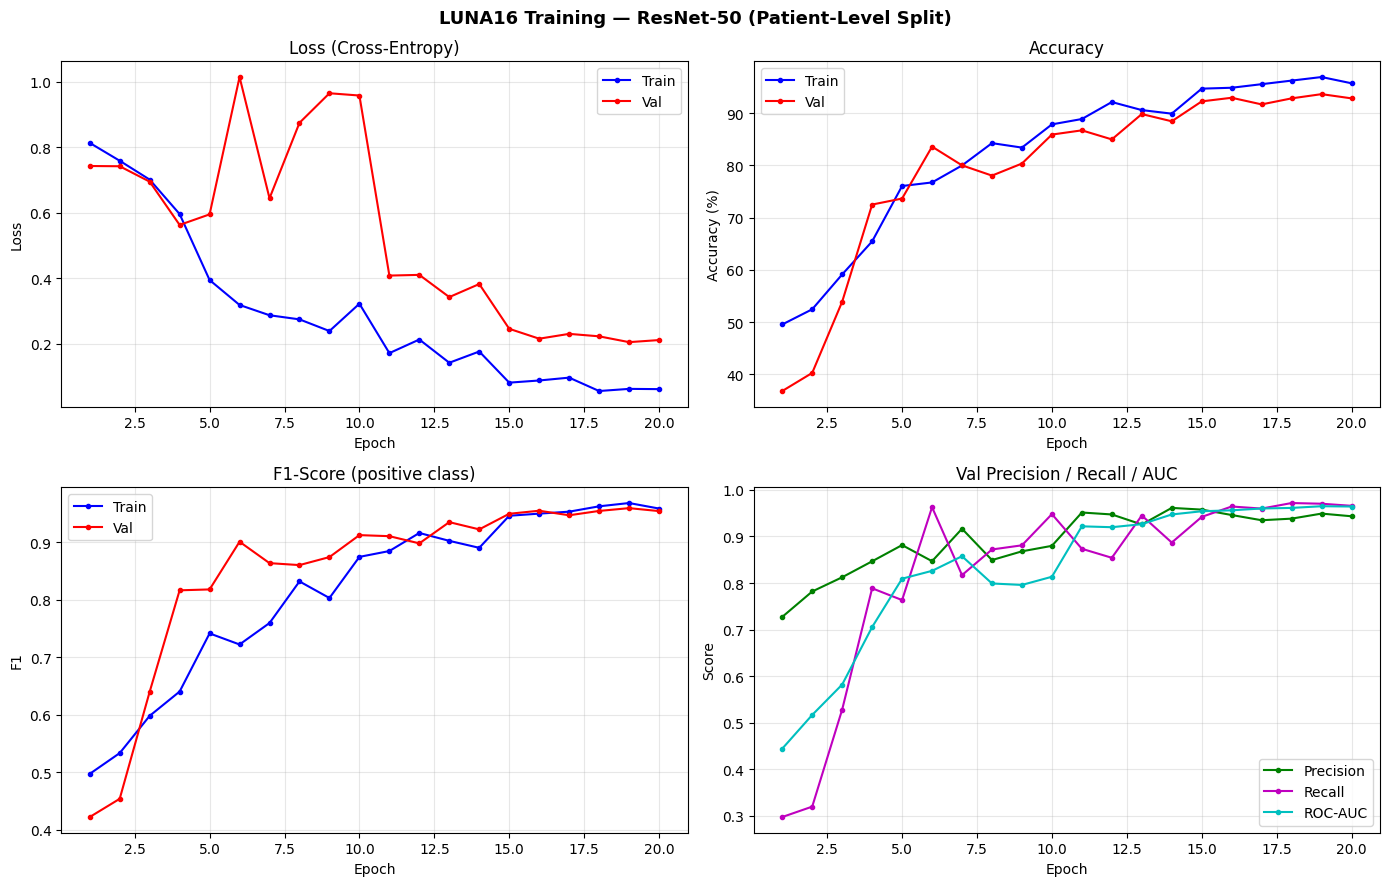

Max train acc - max val acc gap: 3.27% (healthy)
Max train F1  - max val F1  gap: 0.0089


In [7]:
eps = range(1, len(history["train_loss"])+1)
fig, ax = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("LUNA16 Training — ResNet-50 (Patient-Level Split)",
             fontsize=13, fontweight="bold")

ax[0,0].plot(eps, history["train_loss"], "b-o", ms=3, label="Train")
ax[0,0].plot(eps, history["val_loss"],   "r-o", ms=3, label="Val")
ax[0,0].set(title="Loss (Cross-Entropy)", xlabel="Epoch", ylabel="Loss")
ax[0,0].legend(); ax[0,0].grid(alpha=0.3)

ax[0,1].plot(eps, [v*100 for v in history["train_acc"]], "b-o", ms=3, label="Train")
ax[0,1].plot(eps, [v*100 for v in history["val_acc"]],   "r-o", ms=3, label="Val")
ax[0,1].set(title="Accuracy", xlabel="Epoch", ylabel="Accuracy (%)")
ax[0,1].legend(); ax[0,1].grid(alpha=0.3)

ax[1,0].plot(eps, history["train_f1"], "b-o", ms=3, label="Train")
ax[1,0].plot(eps, history["val_f1"],   "r-o", ms=3, label="Val")
ax[1,0].set(title="F1-Score (positive class)", xlabel="Epoch", ylabel="F1")
ax[1,0].legend(); ax[1,0].grid(alpha=0.3)

ax[1,1].plot(eps, history["val_prec"], "g-o", ms=3, label="Precision")
ax[1,1].plot(eps, history["val_rec"],  "m-o", ms=3, label="Recall")
ax[1,1].plot(eps, history["val_auc"],  "c-o", ms=3, label="ROC-AUC")
ax[1,1].set(title="Val Precision / Recall / AUC", xlabel="Epoch", ylabel="Score")
ax[1,1].legend(); ax[1,1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Overfitting quick check
train_val_acc_gap = max(history['train_acc'])*100 - max(history['val_acc'])*100
train_val_f1_gap  = max(history['train_f1'])    - max(history['val_f1'])
print(f"Max train acc - max val acc gap: {train_val_acc_gap:.2f}% "
      f"({'healthy' if train_val_acc_gap < 10 else 'check overfitting'})")
print(f"Max train F1  - max val F1  gap: {train_val_f1_gap:.4f}")


## 7 · Comprehensive Evaluation — 9 Metrics + Threshold Tuning

In [8]:
# Load best checkpoint
ck = torch.load(best_ckpt, map_location=device)
model.load_state_dict(ck["model_state_dict"])
model.eval()
print(f"Loaded best checkpoint — epoch {ck['epoch']}  "
      f"val_f1={ck['val_f1']:.4f}  val_auc={ck['val_auc']:.4f}")

# Inference on val & test (need val probs to tune threshold)
@torch.no_grad()
def infer(loader):
    ys, ss = [], []
    for imgs, lbs in loader:
        imgs = imgs.to(device)
        with autocast('cuda', enabled=USE_AMP):
            out = model(imgs)
        probs = torch.softmax(out.float(), dim=1)[:, 1]
        ss.extend(probs.cpu().numpy()); ys.extend(lbs.numpy())
    return np.array(ys), np.array(ss)

vy, vs = infer(val_loader)
ty, ts = infer(test_loader)

def full_metrics(y_true, y_score, threshold=0.5):
    y_pred = (y_score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "threshold":    float(threshold),
        "accuracy":     float(accuracy_score(y_true, y_pred)),
        "balanced_acc": float(balanced_accuracy_score(y_true, y_pred)),
        "precision":    float(precision_score(y_true, y_pred, pos_label=1, zero_division=0)),
        "recall":       float(recall_score(y_true, y_pred, pos_label=1, zero_division=0)),
        "specificity":  float(tn / (tn + fp)) if (tn + fp) else 0.0,
        "f1":           float(f1_score(y_true, y_pred, pos_label=1, zero_division=0)),
        "mcc":          float(matthews_corrcoef(y_true, y_pred)),
        "roc_auc":      float(roc_auc_score(y_true, y_score)),
        "pr_auc":       float(average_precision_score(y_true, y_score)),
        "confusion":    {"TP": int(tp), "FP": int(fp), "TN": int(tn), "FN": int(fn)},
    }

test_def = full_metrics(ty, ts, 0.5)

# Find optimal threshold on VAL by maximising F1
prec_v, rec_v, thr_v = precision_recall_curve(vy, vs)
f1_v = 2*prec_v*rec_v / (prec_v + rec_v + 1e-12)
best_i = int(np.argmax(f1_v[:-1]))
best_thr = float(thr_v[best_i])
test_opt = full_metrics(ty, ts, best_thr)

print(f"\nOptimal threshold (max val F1) = {best_thr:.4f}")
print("\n" + "="*72)
print(f"  {'Metric':<20} {'@ thr=0.5':>14} {'@ thr='+f'{best_thr:.3f}':>14}")
print("-"*72)
for k in ["accuracy", "balanced_acc", "precision", "recall",
          "specificity", "f1", "mcc", "roc_auc", "pr_auc"]:
    print(f"  {k:<20} {test_def[k]:>14.4f} {test_opt[k]:>14.4f}")
print("="*72)

print("\nClassification report (threshold = 0.5):")
print(classification_report(ty, (ts>=0.5).astype(int),
                             target_names=CLASS_NAMES, digits=4))


Loaded best checkpoint — epoch 19  val_f1=0.9595  val_auc=0.9649



Optimal threshold (max val F1) = 0.5101

  Metric                    @ thr=0.5    @ thr=0.510
------------------------------------------------------------------------
  accuracy                     0.9245         0.9230
  balanced_acc                 0.8961         0.8951
  precision                    0.9571         0.9570
  recall                       0.9461         0.9441
  specificity                  0.8462         0.8462
  f1                           0.9516         0.9505
  mcc                          0.7806         0.7769
  roc_auc                      0.9591         0.9591
  pr_auc                       0.9837         0.9837

Classification report (threshold = 0.5):
              precision    recall  f1-score   support

  non_nodule     0.8121    0.8462    0.8288       143
      nodule     0.9571    0.9461    0.9516       519

    accuracy                         0.9245       662
   macro avg     0.8846    0.8961    0.8902       662
weighted avg     0.9258    0.9245    0.92

## 8 · Metric Comparison Bar Chart

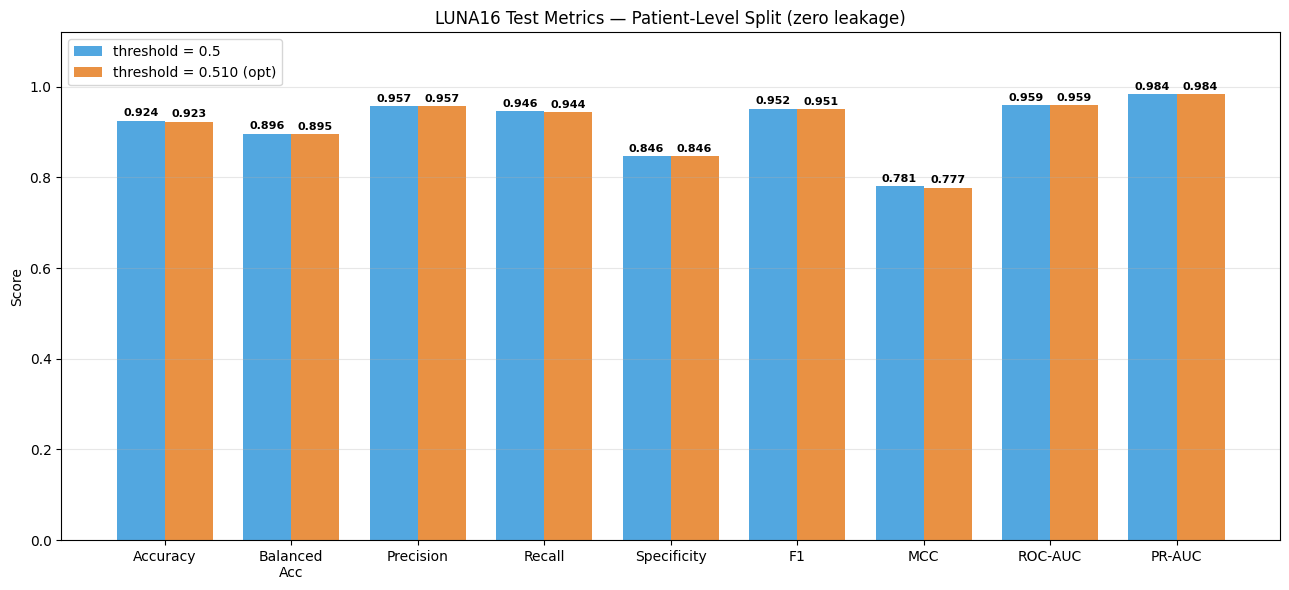

In [9]:
labels_m = ["Accuracy","Balanced\nAcc","Precision","Recall",
            "Specificity","F1","MCC","ROC-AUC","PR-AUC"]
keys_m   = ["accuracy","balanced_acc","precision","recall",
            "specificity","f1","mcc","roc_auc","pr_auc"]
def_vals = [test_def[k] for k in keys_m]
opt_vals = [test_opt[k] for k in keys_m]

x = np.arange(len(labels_m)); w = 0.38
fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.bar(x - w/2, def_vals, w, label="threshold = 0.5", color="#3498db", alpha=0.85)
b2 = ax.bar(x + w/2, opt_vals, w, label=f"threshold = {best_thr:.3f} (opt)", color="#e67e22", alpha=0.85)
for bar, v in zip(list(b1)+list(b2), def_vals+opt_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f"{v:.3f}", ha="center", fontsize=8, fontweight="bold")
ax.set(ylim=(0, 1.12), ylabel="Score", xticks=x, xticklabels=labels_m,
        title="LUNA16 Test Metrics — Patient-Level Split (zero leakage)")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()


## 9 · ROC & Precision-Recall Curves

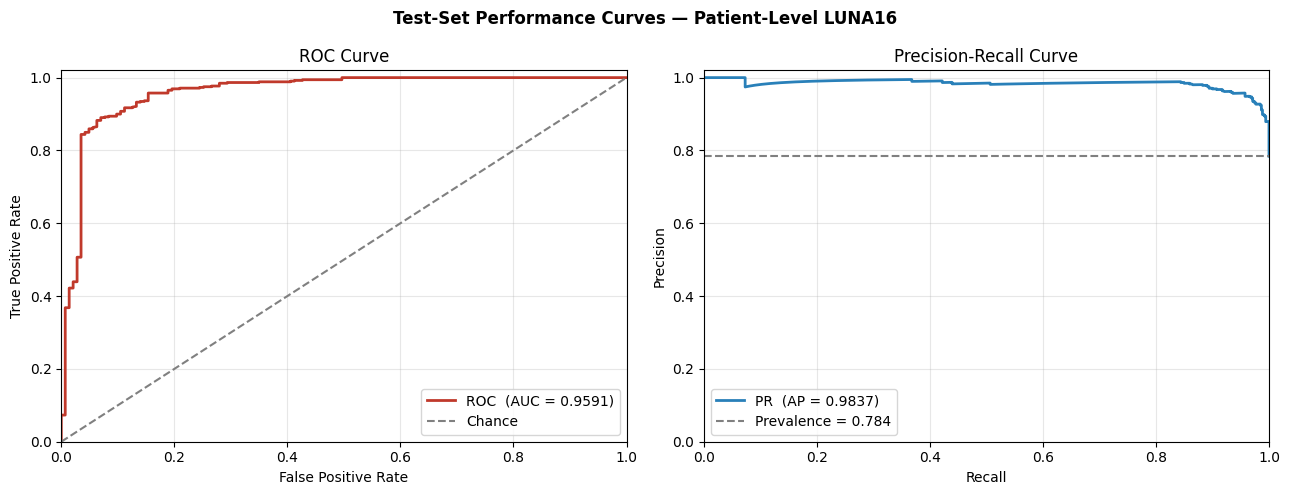

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Test-Set Performance Curves — Patient-Level LUNA16",
             fontsize=12, fontweight="bold")

fpr, tpr, _ = roc_curve(ty, ts)
ax[0].plot(fpr, tpr, lw=2, color="#c0392b",
           label=f"ROC  (AUC = {test_def['roc_auc']:.4f})")
ax[0].plot([0,1],[0,1], "--", color="gray", label="Chance")
ax[0].set(xlim=(0,1), ylim=(0,1.02), xlabel="False Positive Rate",
          ylabel="True Positive Rate", title="ROC Curve")
ax[0].legend(loc="lower right"); ax[0].grid(alpha=0.3)

prec_t, rec_t, _ = precision_recall_curve(ty, ts)
ax[1].plot(rec_t, prec_t, lw=2, color="#2980b9",
           label=f"PR  (AP = {test_def['pr_auc']:.4f})")
base = (ty==1).mean()
ax[1].axhline(base, color="gray", ls="--", label=f"Prevalence = {base:.3f}")
ax[1].set(xlim=(0,1), ylim=(0,1.02), xlabel="Recall", ylabel="Precision",
          title="Precision-Recall Curve")
ax[1].legend(loc="lower left"); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 10 · Confusion Matrices (default vs optimal threshold)

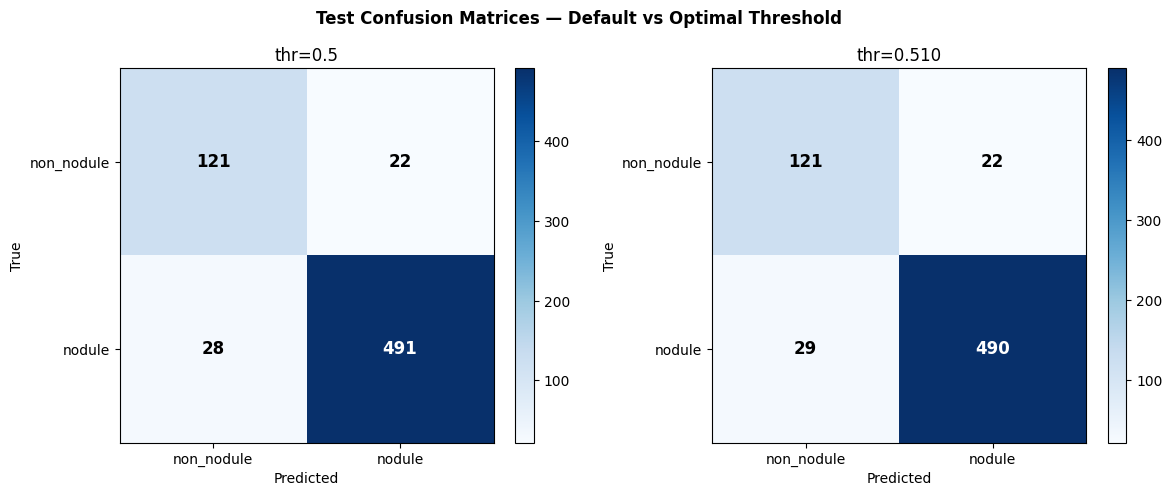

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Test Confusion Matrices — Default vs Optimal Threshold",
             fontsize=12, fontweight="bold")
for a, tm, ttl in [(ax[0], test_def, "thr=0.5"),
                    (ax[1], test_opt, f"thr={best_thr:.3f}")]:
    cm = np.array([[tm['confusion']['TN'], tm['confusion']['FP']],
                   [tm['confusion']['FN'], tm['confusion']['TP']]])
    im = a.imshow(cm, cmap="Blues")
    plt.colorbar(im, ax=a, fraction=0.046)
    a.set(xticks=range(2), yticks=range(2),
          xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
          xlabel="Predicted", ylabel="True", title=ttl)
    th = cm.max()/2
    for i in range(2):
        for j in range(2):
            a.text(j, i, cm[i,j], ha="center", va="center",
                   color="white" if cm[i,j]>th else "black", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()


## 11 · Overfitting Analysis — Train vs Val Gap

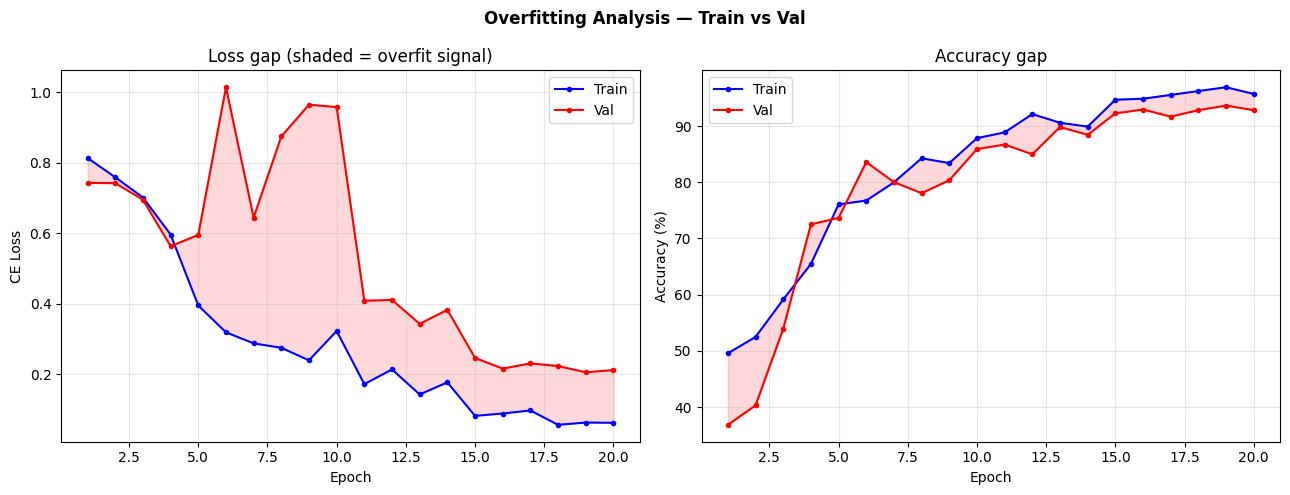

In [12]:
eps = range(1, len(history["train_loss"])+1)
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Overfitting Analysis — Train vs Val", fontsize=12, fontweight="bold")
ax[0].plot(eps, history["train_loss"], "b-o", ms=3, label="Train")
ax[0].plot(eps, history["val_loss"],   "r-o", ms=3, label="Val")
ax[0].fill_between(eps, history["train_loss"], history["val_loss"], alpha=0.15, color="red")
ax[0].set(title="Loss gap (shaded = overfit signal)", xlabel="Epoch", ylabel="CE Loss")
ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].plot(eps, [a*100 for a in history["train_acc"]], "b-o", ms=3, label="Train")
ax[1].plot(eps, [a*100 for a in history["val_acc"]],   "r-o", ms=3, label="Val")
ax[1].fill_between(eps, [a*100 for a in history['train_acc']],
                       [a*100 for a in history['val_acc']], alpha=0.15, color="red")
ax[1].set(title="Accuracy gap", xlabel="Epoch", ylabel="Accuracy (%)")
ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 12 · Final Summary

In [13]:
report = {
    "dataset": "LUNA16 subsets 7-9 (patient-level split)",
    "split": {"train": "subset7", "val": "subset8", "test": "subset9"},
    "model": {"backbone": BACKBONE, "best_epoch": int(ck["epoch"])},
    "val_metrics_at_save": {"f1": float(ck["val_f1"]), "auc": float(ck["val_auc"])},
    "test_threshold_0.5": test_def,
    "test_threshold_optimal": test_opt,
    "optimal_threshold": best_thr,
}
(OUT_DIR/"evaluation_report.json").write_text(json.dumps(report, indent=2))

print("="*66)
print("  LUNA16 — FINAL RESULTS (patient-level, no leakage)")
print("="*66)
print(f"  Backbone       : {BACKBONE}")
print(f"  Best epoch     : {ck['epoch']}  (early stopping patience={EARLY_STOP_PAT})")
print(f"  Test patches   : {len(test_ds)}   (subset9)")
print("-"*66)
print(f"  Accuracy       : {test_def['accuracy']:.4f}")
print(f"  Balanced Acc   : {test_def['balanced_acc']:.4f}")
print(f"  Precision      : {test_def['precision']:.4f}")
print(f"  Recall (Sens.) : {test_def['recall']:.4f}")
print(f"  Specificity    : {test_def['specificity']:.4f}")
print(f"  F1-Score       : {test_def['f1']:.4f}")
print(f"  MCC            : {test_def['mcc']:.4f}")
print(f"  ROC-AUC        : {test_def['roc_auc']:.4f}")
print(f"  PR-AUC         : {test_def['pr_auc']:.4f}")
print("="*66)
print(f"  Confusion: TP={test_def['confusion']['TP']}  "
      f"FP={test_def['confusion']['FP']}  "
      f"TN={test_def['confusion']['TN']}  "
      f"FN={test_def['confusion']['FN']}")
print("="*66)
print(f"\nReport saved to: {OUT_DIR/'evaluation_report.json'}")


  LUNA16 — FINAL RESULTS (patient-level, no leakage)
  Backbone       : resnet50
  Best epoch     : 19  (early stopping patience=6)
  Test patches   : 662   (subset9)
------------------------------------------------------------------
  Accuracy       : 0.9245
  Balanced Acc   : 0.8961
  Precision      : 0.9571
  Recall (Sens.) : 0.9461
  Specificity    : 0.8462
  F1-Score       : 0.9516
  MCC            : 0.7806
  ROC-AUC        : 0.9591
  PR-AUC         : 0.9837
  Confusion: TP=491  FP=22  TN=121  FN=28

Report saved to: luna16_output\evaluation_report.json
